<a href="https://colab.research.google.com/github/venkata18167/-MLA0202---FUNDAMENTALS-OF-MACHINE-LEARNING/blob/main/exp1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Training Dataset:


,Sky,AirTemp,Humidity,Wind,Water,Forecast,EnjoySport
0,Sunny,Warm,Normal,Strong,Warm,Same,Yes
1,Sunny,Warm,High,Strong,Warm,Same,Yes
2,Rainy,Cold,High,Strong,Warm,Change,No
3,Sunny,Warm,High,Weak,Cool,Change,Yes



Initial Hypothesis:
['Ø', 'Ø', 'Ø', 'Ø', 'Ø', 'Ø']

Example 1:
['Sunny', 'Warm', 'Normal', 'Strong', 'Warm', 'Same', 'Yes']
Hypothesis: ['Sunny', 'Warm', 'Normal', 'Strong', 'Warm', 'Same']

Example 2:
['Sunny', 'Warm', 'High', 'Strong', 'Warm', 'Same', 'Yes']
Hypothesis: ['Sunny', 'Warm', '?', 'Strong', 'Warm', 'Same']

Example 4:
['Sunny', 'Warm', 'High', 'Weak', 'Cool', 'Change', 'Yes']
Hypothesis: ['Sunny', 'Warm', '?', '?', '?', '?']

--------------------------------
Final Most Specific Hypothesis:
--------------------------------
['Sunny', 'Warm', '?', '?', '?', '?']


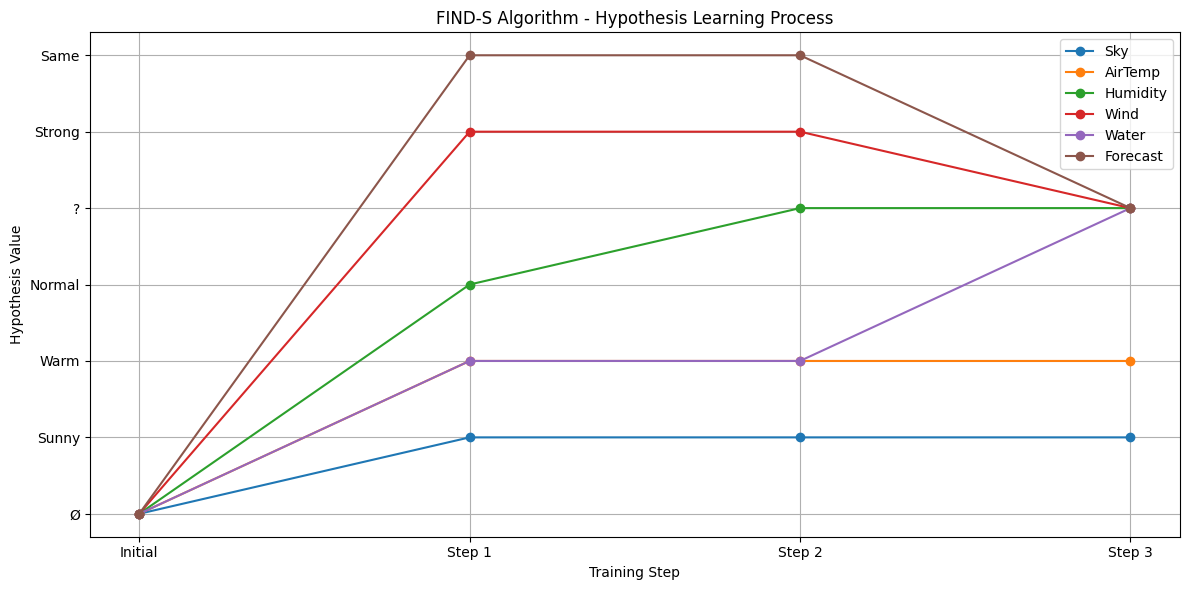

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

data = {
    'Sky': ['Sunny', 'Sunny', 'Rainy', 'Sunny'],
    'AirTemp': ['Warm', 'Warm', 'Cold', 'Warm'],
    'Humidity': ['Normal', 'High', 'High', 'High'],
    'Wind': ['Strong', 'Strong', 'Strong', 'Weak'],
    'Water': ['Warm', 'Warm', 'Warm', 'Cool'],
    'Forecast': ['Same', 'Same', 'Change', 'Change'],
    'EnjoySport': ['Yes', 'Yes', 'No', 'Yes']
}

df = pd.DataFrame(data)

print("Training Dataset:")
display(df)

hypothesis = ['Ø'] * (len(df.columns) - 1)

print("\nInitial Hypothesis:")
print(hypothesis)

hypothesis_history = [hypothesis.copy()]

for index, row in df.iterrows():

    if row['EnjoySport'] == 'Yes':

        for i in range(len(hypothesis)):

            if hypothesis[i] == 'Ø':
                hypothesis[i] = row.iloc[i]

            elif hypothesis[i] != row.iloc[i]:
                hypothesis[i] = '?'

        hypothesis_history.append(hypothesis.copy())

        print(f"\nExample {index + 1}:")
        print(list(row))
        print("Hypothesis:", hypothesis)

print("\n--------------------------------")
print("Final Most Specific Hypothesis:")
print("--------------------------------")
print(hypothesis)

attributes = df.columns[:-1]

fig, ax = plt.subplots(figsize=(12, 6))

for i, attr in enumerate(attributes):
    values = []

    for h in hypothesis_history:
        values.append(h[i])

    ax.plot(
        range(len(values)),
        values,
        marker='o',
        label=attr
    )
ax.set_title("FIND-S Algorithm - Hypothesis Learning Process")
ax.set_xlabel("Training Step")
ax.set_ylabel("Hypothesis Value")

ax.set_xticks(range(len(hypothesis_history)))
ax.set_xticklabels(
    ['Initial'] + [f'Step {i}' for i in range(1, len(hypothesis_history))]
)

ax.grid(True)
ax.legend()
plt.tight_layout()
plt.show()